### The cell below imports a number of python libraries

In [1]:
#%matplotlib inline
import matplotlib
#pylab.rcParams['figure.figsize'] = (8, 6)
from matplotlib import pyplot as plt
import numpy as np
import scipy as sp

from scipy.integrate import solve_ivp
from scipy.optimize import minimize, direct, Bounds, basinhopping, differential_evolution, shgo, dual_annealing

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import colormaps as mcm # mpl colormaps
#import cmasher as cmr # additional colormaps
import colorcet as cc # additional colormaps; 
# note that the last two above are also within mcm(), with prefixes 'cmr_' and 'cet_' respectively

from time import time

import pickle

import itertools as it

from matplotlib import animation
from IPython.display import HTML     # used to display html5 videos

----

## Numerical implementation: Specifying the tissue and its geometry

First, we define the tissue, i.e. a list of cells and their neighbours. For simplicity, we consider a regular grid of cells in the plane. To be more realistic, we allow for a small amount of noise on the cell positions.

### Representing cells and edges

For the model, we need a representation of cells themselves. In particular, we need to identify "edges" between cells to calculate the coefficients $\alpha_{ij}$ before any PD dynamics.

Here is a possible choice of implementation: a "cell" will be described as a list of its "corners", or _"vertices"_ (stored as pairs of coordinates in a list).  
For the purpose of plotting the cells, the list of its vertices will be read by a function to be defined later on, plotting lines between each pair of successive vertices in the list. To ensure that the full cells are plotted, we therefore repeat the first vertex at the end of the list (which for the tissue considered here will thus have 5 elements).  
Below, we define a function which will create all such cells, using the information in vectors X and Y.  
Then, another function will also create a list of all the edges in the tissue, using the information in the list of cells.

In the following, we will rely on the order of cells in the list __cells__ as a reference. In other words, we will consider _cell number i_ to be the $i$ th entry of the Python list __cells__.

To determine adjacencies, we will then build a list of _edges_. In fact we will build two lists. One list __edges__ composed of pairs $[i,j]$ such that cells of index $i$ and $j$ are neighbours, and another list __edge2cell__ which will contain pairs of corners, to be used later to calculate the coefficients $A_{ij}$. To relate the two lists, we will rely on the convention that they are describing edges _in the same order_: the corners in the entry __edge2cell[k]__ will be exactly those between the two cells whose indices are listed in __edges[k]__.


In [2]:
# Spatial parameters:
nx = 5 # cell number (horizontally)
nx_p = 5
ny = 7 # cell number (vertically)
ny_p = 4 # cell number (vertically) // for PIN mutants (smaller tissue)
dx = 1  # cell average width
dy = 1  # cell average height
n = nx*ny # total number of cells
n_p = nx*ny_p # total number of cells
noiz = 0.03 # the amount by which cell positions will be perturbed

# One can now create a regular grid, storing cell corners' coordinates in arrays X and Y:
X,Y = np.meshgrid(np.linspace(0.,dx*nx,nx+1), np.linspace(0.,dy*ny,ny+1)) 
X_p,Y_p = np.meshgrid(np.linspace(0.,dx*nx_p,nx_p+1), np.linspace(0.,dy*ny_p,ny_p+1)) 


# The arrays X and Y are then "reshaped" into vectors, and a noise is introduced
X = X.ravel() + np.random.uniform(-noiz*dx, noiz*dx, X.size) 
Y = Y.ravel() + np.random.uniform(-noiz*dy, noiz*dy, Y.size)  
X_p = X_p.ravel() + np.random.uniform(-noiz*dx, noiz*dx, X_p.size) 
Y_p = Y_p.ravel() + np.random.uniform(-noiz*dy, noiz*dy, Y_p.size)  

# One constructs lists of cell corners; one list for each cell
def create_cells(X,Y, nx, ny):
    cells=[]
    for i in range(nx):
        for j in range(ny):
            cells.append( [
            [ X[i+(1+nx)*j],       Y[i+(1+nx)*j] ], 
            [ X[i+(1+nx)*j+1],     Y[i+(1+nx)*j+1] ],
            [ X[i+(1+nx)*(j+1)+1], Y[i+(1+nx)*(j+1)+1] ],
            [ X[i+(1+nx)*(j+1)],   Y[i+(1+nx)*(j+1)] ],
            [ X[i+(1+nx)*j],       Y[i+(1+nx)*j] ] ] )  # Note that this loops back to the start
    return cells

# Now we actually use the function above
cells = create_cells(X,Y, nx, ny)
cells_p = create_cells(X_p,Y_p, nx_p, ny_p)

# Now the function below determines which pairs of cells are adjacent
def create_edges(cells, nx=nx, ny=ny):
    n = nx*ny
    # Make the link between edges of the adjacency graph and borders of cells
    # First, represent every cell by its corner points, seen as a set
    setcells = [set([tuple(c) for c in C]) for C in cells]
    
    ## Create a list 'edges' (i.e. neighbouring pairs of cells), and a list 'edge2cell'  
    ## with the same length as edges, such that entry i contains the 
    ## two corner points of the wall corresponding to the edge edges[i]
    edges=[]
    edge2cell=[]
    for i in range(len(cells)):
        for di in [1,ny]:##[-1,1,-ny,ny]:
            if i+di in range(n):
                tmp = setcells[i] & setcells[i+di] 
                if (tmp!= set()) & (len(tmp)==2):
                    edge2cell.append(list(tmp))
                    edges.append( tuple([i,i+di]) )
    #edges = np.array(edges)
    return edges, edge2cell

edges, edge2cell = create_edges(cells)
m = len(edges) # number of adajacent pairs
edges_p, edge2cell_p = create_edges(cells_p, nx=nx_p, ny=ny_p)
m_p = len(edges_p) # number of adajacent pairs

## We now have all the information to calculate the $V_i$ and $\alpha_{ij}$ coefficients, and store them in arrays.


# centroids[i,:] is the centroids of points in cells[i]
def create_centroids(cells=cells):
    return np.array( [[np.sum([cc[0] for cc in c[:-1]])/(len(c)-1), 
                   np.sum([cc[1] for cc in c[:-1]])/(len(c)-1)] for c in cells])

centroids = create_centroids(cells)
centroids_p = create_centroids(cells_p)

# vols[i] is the volume (in fact, area) of the "rectangle" in cells[i] ::: "Vi"
# the function below relies on a triangulation of the cell and a well known property 
# of the cross product.
def compute_vols(cells=cells, centroids=centroids):
    return np.array([np.sum(np.abs(np.cross(cells[i][0:-1]-centroids[i],
                     cells[i][1:]-centroids[i]))) for i in range(len(cells))])

vols = compute_vols(cells=cells, centroids=centroids)
vols_p = compute_vols(cells=cells_p, centroids=centroids_p)


# We could call the below a "weighted adjacency matrix". First one builds a dictionary whose 
# keys are edges (i,j), and entries are pairs of (floating) numbers, representing permeabilities of 
# (i,j) and (j,i) respectively. Initially, they are identical.
init_wall_perms = [ np.linalg.norm(np.array(e[1])-np.array(e[0])) for e in edge2cell] # init values for either Eij or Eji
adj_dic = dict(zip(edges, list(zip( init_wall_perms, init_wall_perms ) )) )# Dictionary with entries like  (i,j): (Eij, Eji)


init_wall_perms_p = [ np.linalg.norm(np.array(e[1])-np.array(e[0])) for e in edge2cell_p] # init values for either Eij or Eji
adj_dic_p = dict(zip(edges_p, list(zip( init_wall_perms_p, init_wall_perms_p ) )) )# Dictionary with entries like  (i,j): (Eij, Eji)

def adj_mat(infodic = adj_dic, n=n):
    # The input data infodic should be a dictionary with keys (i,j) for nonzero entries of the 
    # matrix, and values the expected λij, λji parameters (as a 2-tuple).
    wAdj = np.zeros((n,n))
    for i,j in infodic.keys():
        wAdj[i,j] = infodic[(i,j)][0]
        wAdj[j,i] = infodic[(i,j)][1]
    return wAdj 

wAdj = adj_mat(adj_dic)
wAdj_p = adj_mat(adj_dic_p, n=n_p)

def inc_mat(info_dic = adj_dic, n=n):
    # The input data infodic should be a dictionary with keys (i,j) and values 
    # for the weight of the edge (i,j). 
    # NB: relies on dict keys being returned in insertion order, which is only guaranteed
    #     for python >3.7
    # Returns the weighted incidence matrix A of size #edges x #nodes such that for e=(i,j) one has 
    # if i<j, then A[e,i] = -A[e,j] = |infodic[(i,j)]| (absolute value) 
    # and the opposite value if i>j.
    m = len(info_dic)

    wAdj = np.zeros((m,n))
    for k,(i,j) in enumerate( info_dic.keys() ):
        if i<j:
            wAdj[k, i] = info_dic[(i,j)][1]-info_dic[(i,j)][0]#-np.abs( info_dic[(i,j)] )
        else: 
            wAdj[k, i] = info_dic[(i,j)][0]-info_dic[(i,j)][1]#np.abs( info_dic[(i,j)] )
        wAdj[k,j] = -wAdj[k,i]
    return wAdj 
    
Jmat = inc_mat(adj_dic) # Incidence matrix
Jmat_p = inc_mat(adj_dic_p, n=n_p) # Incidence matrix

/tmp/ipykernel_172638/1430819549.py:82: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.array([np.sum(np.abs(np.cross(cells[i][0:-1]-centroids[i],


### Graphical display

We now have defined all the elements required to display a tissue and use it a support for the morphogen gradient model.

We define below function `plot_geom()`, which uses matplotlib predefined routines for the plotting of polyhedra.  

Important arguments of this function are the list __cells__ and the array __cvals__, which is set by default to take random values but will be used later to contain the concentrations $x_i$ for all cells $i\in\{1...N\}$. It also takes a colormaps __ccol__ and __wcol__ as argument, by default set to greeny/purply, but which you may wish to change.




In [3]:

# Show the tissue geometry, with colormaps based on morphogen levels
cola = mcm['YlGn']                             #  mcm['cet_kgy_r'] 
colp = mcm['cet_linear_ternary_red_0_50_c52']  #  mcm['cet_bmw_r'] 

def plot_geom(ax=None, cells=cells, cvals=np.random.rand(n), wvals=None, cvalmax=None, wvalmax=None, nx=nx, ny=ny,
              shrk=0.1*dx, alpha=1, ccol=cola, wc='yellow',cbar=False, wbar=False, wcol=colp, ew=1, title=None, 
              X=X, Y=Y):
    if ax is None:
#        fig=figure()
        if cbar:
            ax = plt.subplot(121, facecolor = [.6,.6,.6]) #, aspect=1)
        else:
            ax = plt.subplot(111, facecolor = [.6,.6,.6]) #, aspect=1)fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4,4),facecolor= [.6,.6,.6]);

    edges, edge2cell = create_edges(cells, nx=nx, ny=ny)
    centroids = create_centroids(cells)
    
    if cvalmax is None: cvalmax = np.max(cvals)

    for idx in range(len(cells)):
        cell = cells[idx]
        aa = cvals / cvalmax
        codes = [matplotlib.path.Path.MOVETO] \
            + [matplotlib.path.Path.LINETO] * (len(cell)-2) \
            + [matplotlib.path.Path.CLOSEPOLY]
        path = matplotlib.path.Path(cell,codes)
        color = ccol(aa[idx]) 
        if wvals is None:
            patch = matplotlib.patches.PathPatch(
                path, facecolor=color, edgecolor=wc, lw=ew, zorder=-1, alpha=alpha)
        else: 
            patch = matplotlib.patches.PathPatch(
                path, facecolor=color, edgecolor=None, zorder=-1, alpha=alpha)
        ax.add_patch(patch)

    # wall colouring according to wvals: NB: uses global variables e.g. "edges" etc.
    if wvals is not None:
        if wvalmax is None: wvalmax = np.max(wvals)
        
        for i,e in enumerate(edges):
        #    idx = edges[eid][0]
        #    cc = np.array(list(e2c[idx])).transpose()
            cc = edge2cell[i]
            dij = np.array( cc - centroids[e[0]])
            dji = np.array( cc - centroids[e[1]])
            nij = 1./np.apply_along_axis(np.linalg.norm,1,dij)
            nji = 1./np.apply_along_axis(np.linalg.norm,1,dji)
            dij = np.dot(np.diag(nij),dij)
            dji = np.dot(np.diag(nji),dji)
            XY = cc[0], cc[1], cc[1] - shrk*dij[1],cc[0]-shrk*dij[0]
            brdr = matplotlib.patches.Polygon(xy=(XY), color= wcol(wvals[e[0],e[1]]/wvalmax), alpha=alpha, ec='none')
            ax.add_patch(brdr)
            XY = cc[0], cc[1], cc[1] - shrk*dji[1],cc[0]-shrk*dji[0]
            brdr = matplotlib.patches.Polygon(xy=(XY), color= wcol(wvals[e[1],e[0]]/wvalmax), alpha=alpha, ec='none')
            ax.add_patch(brdr)
        
    ax.set_xlim(np.min(X)-dx/4, np.max(X)+dx/4)
    ax.set_ylim(np.min(Y)-dy/4, np.max(Y)+dy/4)
    ax.set_xticks([])
    ax.set_yticks([])
    if cbar:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes( "right", size="15%", pad=0.05)
        nrm = matplotlib.colors.Normalize(vmin= 0, vmax=cvalmax )
        cb = matplotlib.colorbar.ColorbarBase(cax, cmap=ccol, norm=nrm, orientation='vertical')
        ticks = np.round(np.linspace(0, cvalmax, 5), 2) 
        cb.set_ticks( labels=ticks, ticks=ticks, fontsize = 8)
        if wbar:
            cax = divider.append_axes( "bottom", size="4%", pad=0.05 )
            nrm = matplotlib.colors.Normalize(vmin= 0, vmax= wvalmax )
            cb = matplotlib.colorbar.ColorbarBase(cax, cmap=wcol, norm=nrm, orientation='horizontal')
            ticks = np.round(np.linspace(0, wvalmax, 5), 2)
            cb.set_ticks(ticks=ticks, labels= ticks, rotation=45, fontsize = 8)
    elif wbar:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes( "bottom", size="4%", pad=0.05)
        nrm = matplotlib.colors.Normalize(vmin= 0, vmax= wvalmax )
        cb = matplotlib.colorbar.ColorbarBase(cax, cmap=wcol, norm=nrm, orientation='horizontal')
        ticks = np.round(np.linspace(0, wvalmax, 5), 2)
        cb.set_ticks(ticks=ticks, labels= ticks, rotation=45, fontsize = 8)

        
    if not (title is None):
        ax.title.set_text( title )

## Some convenience funnctions which may be of use later.

# Conversion from vector to matrix of the Pij's
def v2m(p):
    I,J = wAdj.nonzero()
    P=np.zeros((n,n))
    P[I,J]=p
    return P

# Conversion from matrix to vector
def m2v(P):
    I,J = wAdj.nonzero()
    return P[I,J]

colfx =  mcm['cet_bmy']#.resampled(50)

## This routine display auxin fluxes as arrows
def plot_graph(ax, Flx = np.ones(len(edges)), fcol = colfx, ec='w', alpha=.9, width=.5, edges=edges, tol=1e-12, centroids=centroids): ##, ms=6):
    lmbd = .1
    for k,(i,j) in enumerate( edges ):
        Fij = Flx[k]  ##Adj[k]*( a[i]-a[j] )
        sgn = np.sign( Fij )
        dx, dy = (centroids[j] - centroids[i])*sgn
        vec = np.array([dx,dy])
        if sgn > 0 :
            arx,ary = centroids[i] + lmbd*vec
        elif  sgn < 0 :
            arx,ary = centroids[j] + lmbd*vec
        nPhij = np.abs(Fij) #/ np.max( np.abs(Fij) )
        if nPhij > tol:
            if isinstance(fcol, str): fc= fcol 
            else: fc= fcol( nPhij )  #fcol( Fij )
            arr = matplotlib.patches.Arrow(arx,ary,(1-2*lmbd)*dx, (1-2*lmbd)*dy, facecolor=fc , edgecolor=ec,lw=.5, width= nPhij*width, alpha=alpha)
            ax.add_patch(arr)


In [4]:
# PD_target_vec = np.array( [1 if k in [9,11,13,15, 18,20,22,24, 27,29,31,33] else 0 for k in range(m) ])
# PD_target_vec = np.array( [1 if k in [13,15,17,19,21,23, 26,28,30,32,34,36, 39,41,43,45,47,49 ] else 0 for k in range(m) ])
# PD_target = adj_mat( dict(zip(edges, [PD_target_vec[k] for k in range(len(edges))])) )

## The cell below finally implements the ODE model discussed at the beginning of this page. Comments within it may help understand how this is done. 

But, in short, after running the cell below one owns a new function, called `plasmo_dyn`, which calculates the right-hand side of our ODE model. This function can in particular be solved (a.k.a. ''integrated'') numerically using for instance a python function called `solve_ivp`.


One specific situation which will be considered in the following is where $k$ is a Boolean vector, equal to $1$ on a subset of "source" cells $S\subset C$. 

One will also consider a special case where degradation is identical in all cells, except for "removal" subset $R\subset C$ in which degradation occurs at a higher rate:
$$\delta_i=\left\{\begin{array}{ll}
		 \delta & \text{if }\quad i\not\in R\\[2mm]
		 \delta_+ & \text{if }\quad i\in R,
         \end{array}\right.\qquad \text{with}\quad \delta_+>\delta.
$$


In [5]:
### k = 1.0    # default auxin production rate ### Superseded by S_vals below
tau_final = 100.0 # the time (at timscale τ) at which time-stepping stops
#tau_ratio = .75
#tau_inf = tau_final*tau_ratio # time horizon for intrisic PD closure

P= 1.0     # permeability, 
T= 1.0      # nominal active transport rate
δ= 0.01    # degradation rate for auxin
S0 = 0.0   # default production rate (without YUCCA), expected low
μ = 1   # degradation rate for plasmodesmata
η = 1   # degradation rate for PIN
nht = 2     # Hill exponent, for the tau dependent PD closure

rho_0 = 0.01 # background/minimal diffusivity, added to walls as a constant

tau_infPD = 125
rhoPD = μ* np.max(wAdj)       # Amplitude for the Hill function; chosen to match the initial wall sizes, normalized with μ to make equilibrium ~1.
nhPD = 2                    # Hill exponent, for the plasmodesmata rate
thPD= 0.2 # 0.5               # Hill threshold, for the plasmodesmata rate. If set to np.inf, a power function φ^n  will be used instead of Hill.

tau_infPIN = np.inf
rhoPIN =  η* np.max(wAdj)  # 0    # Amplitude for the Hill function; chosen to match the initial wall sizes, normalized with η to make equilibrium ~1.
nhPIN = 2                   # Hill exponent, for the PIN rate
thPIN= 0.3 # 0.5               # Hill threshold, for the PIN rate. If set to np.inf, a power function φ^n  will be used instead of Hill.

pars_default = P, T, rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN

### Relative contributions of active (PIN, asymmetric) and passive (PD, diffusive symmetric) transort; at ξ=0 is pure PD, at ξ=1 pure PIN.
##ξ = 0 # 0: pure PD || 1: pure PIN 

#ε = 1e-6 # Time scale separator; NB only relevant when using a "full" model without qss assumption. 

# Some Defaults for source and sinks:
S_vals = np.array([.01, .8, 1., .8, .01])  ## The left column as a high production rate in the middle.
# S_vals = np.array([.1, .8, 1., .8, .1])
# S_vals = np.array([.01, .01, 1., .01, .01]) 

#S_vals_series =  [ S_vals0*(1-(i/nb_iter)**2) for i in range(nb_iter)]
#S_vals_series =  [ S_vals0**(2*i+1) for i in range(nb_iter)]
#S_vals_series =  [ S_vals0 for i in range(nb_iter)]
#prod_default = np.hstack( ( S_vals, [S0]*(n-len(S_vals))) )  ## A centre peak on left column, the rest at S0
prod_default = S0*np.ones(n) ## A centre peak on top row, the rest at S0
prod_default[ny-1::ny] = S_vals

prod_spotty= np.random.uniform(0,.01,n)
i_spots = np.random.choice(n, 2)
for i in i_spots: prod_spotty[i] += 1



R_vals = [100.0]*nx
#degr_default = np.hstack( ([δ]*(n-len(R_vals)), R_vals) )  ## A rate as in R_vals on right column, rest at default (=δ)
degr_default = δ*np.ones(n)  ## A rate as in R_vals on bottom row, rest at default (=δ)
degr_default[::ny] = R_vals

#degr_homog = δ*np.ones(n) 
#degr_now = degr_default

## Some functions of use to determine a steady state of auxin, given a pattern of production/degradation and a 
## permeability matrix.
def indicatrix(I, n=n):
    # Convenience function returing a 0./1. array matching indices in I
    return np.array( [1. if i in I else 0. for i in range(n) ] )

def sink(I, δ0=δ, δ1= 2*δ ):
    # Convenience function defining higher decay rates in cells indexed by I.
    # 1st parameter δ0 is the base decay rate, 2nd parameter δ1 is added for cells in I.
    return (δ0+δ1)*indicatrix(I) + δ0*( 1-indicatrix(I) )


def laplace_matrix(wAdj=wAdj):
    Lap =  wAdj - np.diag( np.sum(wAdj, axis=1) ) 
    return Lap

# P = 1.0
# Lap = laplace_matrix(wAdj=wAdj, P=P)  # Laplacian matrix

# def rhs_mat(Lap=Lap, degr = sink(range(20,n)), vols=vols ):
#     L = np.dot(np.diag(1./vols), Lap) # scale Laplacian by cell volumes
#     return np.linalg.inv( np.diag(degr) - L  ) 

# def auxin_equil( Lap=Lap, prod = prod_default, degr = degr_default ,  vols=vols):
#     L = np.dot(np.diag(1./vols), Lap) # scale Laplacian by cell volumes
#     return np.linalg.solve( np.diag(degr) - L , prod ) 


##pars = rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN
parnames = ['P', 'T',r'$\rho_0$','δ', 'S0', 'μ', 'η', r'$n_{ht}$',r'$\tau_{\infty PD}$', r'$n_{hPD}$', r'$\theta_{PD}$', 
            r'$\tau_{\infty PIN}$', r'$n_{hPIN}$', r'$\theta_{PIN}$', r'$\rho_{PD}$', r'$\rho_{PIN}$']

def h(tau, phi, nh=nhPD, th=thPD, rho=rhoPD , tau_inf=tau_infPD, nht=nht):
    # The function relating plasmodesmata "status" in terms of the auxin flux through 
    # the membrane where they are considered. As default we take a Hill function with 
    # steepness and thresholds parameters nh and th respectively.
    if tau_inf != np.inf:
        time_decr =  (tau/tau_inf)**nht
    else: # infinite τ∞ amounts to removing the denominator term; NB strictly speaking the if:else: isn't required since 1/np.inf==0
        time_decr = 0

    if th != np.inf: # Corresponds to Hill function 
        #y =  rho*phi**nh/( th**nh + (phi+ time_decr)**nh )
        y =  rho*phi**nh/( th**nh + phi**nh + time_decr )
    else: # Corresponds to power function (with time decrease perhaps)
        y =  rho*phi**nh / ( 1+time_decr )
    return y

def walls_to_aux(W, prod=prod_default, degr=degr_default, vols=vols):
    # Arrange W into a matrix, used to determine the Laplacian given current PD opening status.
    Lap = laplace_matrix( W )
    # Deduce the (uniquely defined) equilibrium distribution of auxin for this L
    L = np.dot(np.diag(1./vols), Lap) # scale Laplacian by cell volumes
    return np.linalg.solve( np.diag(degr) - L , prod ) 


def make_flux(a, AP, edges=edges, P=P, T=T):
    # a is a vector of auxin concentrations
    # AP is a 3*m vector containing α (plasmodesmata) and rho (PIN) parameters, in the order made 
    # clear by the setting of PD, PINup and PINdown variables below
    m = len(edges)
    PD = AP[:m]
    PINup, PINdown = AP[m:2*m], AP[2*m:]
    return np.array( [ ( P*PD[k]+T*PINup[k] )*a[i] - ( P*PD[k]+T*PINdown[k] )*a[j] for k,(i,j) in enumerate(edges)] )


def full_dyn(t, AP, pars=pars_default, edges=edges, prod = None, degr = None, vols=vols ):
    # AP is a 3*m + n vector containing α (plasmodesmata), rho (PIN) parameters and a (auxin concθ), in the order made 
    # clear by the setting of PD, PINup and PINdown variables below
    #δ, S0, μ, tau_final, tau_inf, nht, nh, th = pars
    #rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN = pars
    P, T, rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN = pars
    m = len(edges)
    PD = AP[:m]
    PINup, PINdown = AP[m:2*m], AP[2*m:3*m]
    a = AP[3*m:]
    n = len(AP) - 3*m

    if prod is None:
        prod = S0*np.ones(n) ## A centre peak on top row, the rest at S0
        prod[ny-1::ny] = S_vals

    if degr is None:
        R_vals = [10]*nx
        #degr_default = np.hstack( ([δ]*(n-len(R_vals)), R_vals) )  ## A rate as in R_vals on right column, rest at default (=δ)
        degr = δ*np.ones(n)  ## A rate as in R_vals on bottom row, rest at default (=δ)
        degr[::ny] = R_vals

    # Calculate the (uniquely defined) equilibrium distribution of auxin for this PD distribution
    adj_dic = dict( zip(edges, list(zip( P*PD+T*PINup,    P*PD+T*PINdown  ) )) )
    M = np.dot( np.diag(1./vols),  laplace_matrix( adj_mat(adj_dic, n=n) ) ) - np.diag(degr)
    da = prod - np.dot(M, a)
    ###a = walls_to_aux( adj_mat(adj_dic), prod=prod, degr=degr)

    # Compute the current flux
    flx = make_flux(a, AP, edges=edges, P=P, T=T)
    
    dPD      = ( rho_0 + h(t, np.abs(flx) ,      nh=nhPD,  th=thPD,  rho=rhoPD ,  tau_inf=tau_infPD,  nht=nht) ) - μ*PD
    dPINup   = ( rho_0 + h(t, np.max(flx, 0)  ,  nh=nhPIN, th=thPIN, rho=rhoPIN , tau_inf=tau_infPIN) ) - η*PINup
    dPINdown = ( rho_0 + h(t, np.max(-flx, 0) ,  nh=nhPIN, th=thPIN, rho=rhoPIN , tau_inf=tau_infPIN) ) - η*PINdown

  #  return  np.concatenate( (dPD, dPINup, dPINdown, da/ε) )
    return  np.concatenate( (ε*dPD, ε*dPINup, ε*dPINdown, da) )
  #  return  np.concatenate( (dPD, dPINup, dPINdown, da) )

def qss_dyn(t, AP, pars=pars_default, edges=edges, prod = None, degr = None , vols=vols):
    # AP is a 3*m vector containing α (plasmodesmata) and rho (PIN) parameters, in the order made 
    # clear by the setting of PD, PINup and PINdown variables below
    #δ, S0, μ, tau_final, tau_inf, nht, nh, th = pars
    #rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN = pars
    P, T, rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN = pars
    m, n = len(edges), len(vols)
    PD = AP[:m]
    PINup, PINdown = AP[m:2*m], AP[2*m:]

    if prod is None:
        prod = S0*np.ones(n) ## A centre peak on top row, the rest at S0
        prod[ny-1::ny] = S_vals

    if degr is None:
        R_vals = [10]*nx
        #degr_default = np.hstack( ([δ]*(n-len(R_vals)), R_vals) )  ## A rate as in R_vals on right column, rest at default (=δ)
        degr = δ*np.ones(n)  ## A rate as in R_vals on bottom row, rest at default (=δ)
        degr[::ny] = R_vals

    # Calculate the (uniquely defined) equilibrium distribution of auxin for this PD distribution
    adj_dic = dict( zip(edges, list(zip( P*PD+T*PINup, P*PD+T*PINdown) ) ) )
    a = walls_to_aux( W = adj_mat(infodic=adj_dic, n=n), prod=prod, degr=degr, vols=vols)

    # Compute the current flux
    flx = make_flux(a, AP, edges=edges, P=P, T=T)
    
    dPD      = ( rho_0 + h(t, np.abs(flx) ,      nh=nhPD,  th=thPD,  rho=rhoPD ,  tau_inf=tau_infPD,  nht=nht) ) - μ*PD
    dPINup   = ( rho_0 + h(t, np.max(flx, 0)  ,  nh=nhPIN, th=thPIN, rho=rhoPIN , tau_inf=tau_infPIN) ) - η*PINup
    dPINdown = ( rho_0 + h(t, np.max(-flx, 0) ,  nh=nhPIN, th=thPIN, rho=rhoPIN , tau_inf=tau_infPIN) ) - η*PINdown

    return  np.concatenate( (dPD, dPINup, dPINdown) )

def aux_in(t, n=n, nz=0, t0=0., t1=20.):
    return ( np.ones(n) + np.random.uniform(-nz,nz,n) )*( (t > t0)*(t< t1) )

H = lambda x,y,kx=1,ky=1,k0=1, nI=2, nA=2, k_b=0 : (k_b + kx*(x**nA) )/( kx*(x**nA) + ky*(x**nA)*(y**nI) + k0 )

# def aux_readout(t,X, pars=[1,1,1, 2,2] , aux_in=aux_in):
#     return [] ## Placeholder

def RGN_ode(t,X, pars=[1,1,1, 2,2, 0] , aux_in=aux_in, n=n):
    A, I, R = X[:n], X[n:2*n], X[2*n:] ##X[::3], X[1::3], X[2::3] ##
    
    if len(pars) == 8:
        kAx, kAy, nAA, kIx, kIy, nAI, kBx, kBy, nAR = list(pars[:3])*3
        nI, k_b, aux_in_th, dx  = pars[3:]
    elif len(pars) == 13 :
        kAx, kAy, nAA, kIx, kIy, nAI, kBx, kBy, nAR, nI, k_b, aux_in_th, dx = pars
    else:
        print("Not admissible parameter vector.")
        return None
    dARF = np.zeros(n)
    dIAA = np.zeros(n)
    #dATHB = np.zeros(n)
    dATHB = np.zeros(n)

    for i in range(n):
        dARF[i]  = H(A[i],I[i], kAx, kAy, 1, nI, nAA, k_b) - A[i]
        dIAA[i]  = H(A[i],I[i], kIx, kIy, 1, nI, nAI, k_b) - dx*( .1*aux_in_th+aux_in(t)[i] )/( aux_in_th+aux_in(t)[i] ) *I[i]
        #dATHB[i] = H(A[i],I[i], kBx, kBy, kB0, nI, nA) - B[i]
        dATHB[i] = H(A[i],I[i], kBx, kBy, 1, nI, nAR, 0) - R[i]
    return np.concatenate( (dARF, dIAA, dATHB) )

def aux_to_ATHB8_ss(a, X0=np.random.uniform(0,1,3*n), pars = [1,1,4, 1,1,4, .1,1,4, 2, 0, .1,1] , n=n ):
    aux_in = lambda t : a
    sol = solve_ivp(RGN_ode, t_span=[0, 100],y0= X0, method='RK45', args= ( pars, aux_in, n, ))
    return sol.y[:,-1]

# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(2,3),); # Create a figure
# plot_geom(ax, cvals= prod_spotty, ccol=mcm['ocean_r'])

Text(0.5, 1.1, '$t_{final}=$100.0  P=1.0,  T=1.0,  $\\rho_0$=0.01,  δ=0.01,  S0=0.0,  μ=1,  η=1,  $n_{ht}$=2,  $\\tau_{\\infty PD}$=125,  $n_{hPD}$=2,  $\\theta_{PD}$=0.5,  $\\tau_{\\infty PIN}$=inf,  $n_{hPIN}$=2,  $\\theta_{PIN}$=0.5,  $\\rho_{PD}$=2.11,  $\\rho_{PIN}$=0.0')

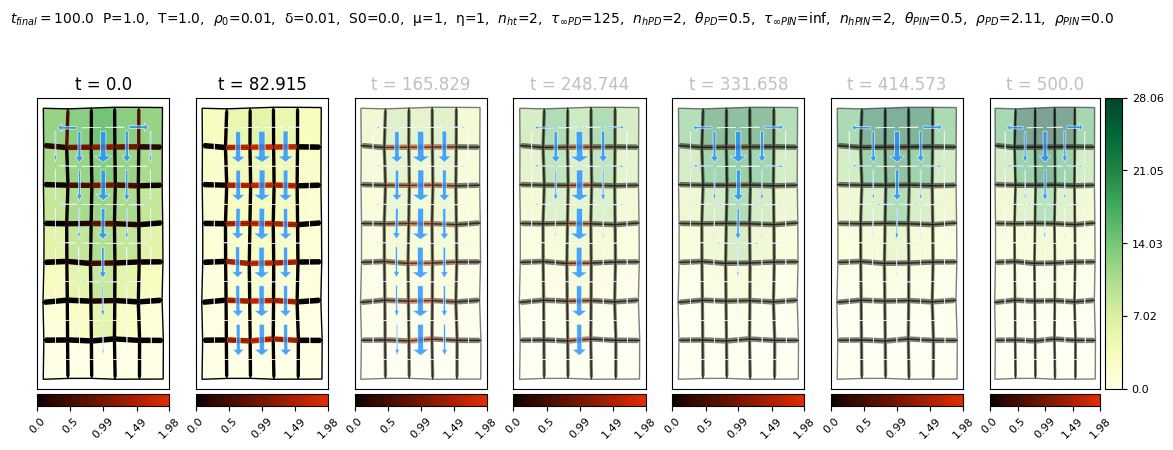

In [6]:
##### Now, the `solve_ivp` tool from the scipy library can be used to integrate the ODEs and produce a time series, saved in the variable `PD_series`.

prod= prod_default

#degr_default = np.hstack( ([δ]*(n-len(R_vals)), R_vals) )  ## A rate as in R_vals on right column, rest at default (=δ)
degr = δ*np.ones(n)  ## A rate as in R_vals on bottom row, rest at default (=δ)
degr[::ny] = [100.0]*nx

#degr=degr_default

#Initial condition 
t = np.linspace(0,5*tau_final,200)
ratio = 1#1
adj_dic_00 = dict( zip(edges, list(zip( np.zeros(len(edges)), np.zeros(len(edges))  ) ) ) )
Lap_00 = laplace_matrix( adj_mat(adj_dic_00, n=n) )
AP_00 =  np.concatenate( (np.array([ratio*Lap_00[i,j] for i,j in edges]), np.zeros(len(edges)), np.zeros(len(edges)) ) )

#AP_0 =  np.concatenate( (np.array([ratio*Lap[i,j] for i,j in edges]), np.zeros(len(edges)), np.ones(len(edges)) ) )#

# Set parameters and run solve_ivp
pars = pars_default # Reset to default 
### Uncomment and change for manual exploration
P= 1.0     # permeability, 
T= 1.0      # nominal active transport rate
δ= 0.01    # degradation rate for auxin
S0 = 0.0   # default production rate (without YUCCA), expected low
μ = 1   # degradation rate for plasmodesmata
η = 1   # degradation rate for PIN
nht = 2     # Hill exponent, for the tau dependent PD closure

rho_0 = 0.01 # background/minimal diffusivity, added to walls as a constant

tau_infPD = 125 #0.01#0.1#np.inf#125 
rhoPD = 2*μ* np.max(wAdj)       # Amplitude for the Hill function; chosen to match the initial wall sizes, normalized with μ to make equilibrium ~1.
nhPD = 2                    # Hill exponent, for the plasmodesmata rate
thPD = .5 # 0.5               # Hill threshold, for the plasmodesmata rate. If set to np.inf, a power function φ^n  will be used instead of Hill.

tau_infPIN = np.inf
rhoPIN = 0.0*η* np.max(wAdj)      # Amplitude for the Hill function; chosen to match the initial wall sizes, normalized with η to make equilibrium ~1.
nhPIN = 2                   # Hill exponent, for the PIN rate
thPIN= 0.5 # 0.5               # Hill threshold, for the PIN rate. If set to np.inf, a power function φ^n  will be used instead of Hill.

pars = P, T, rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN


#args =  (pars, ξ, edges, None, None)
args =  (pars, edges, prod, degr, vols,)

### QSS-like reduced model
AP_pre = solve_ivp(qss_dyn, t_span=[0, 1],y0= AP_00, method='RK45', args=args)
AP_01 = AP_pre.y[:,-1]

AP_sol = solve_ivp(qss_dyn, t_span=[t[0],t[-1]], t_eval=t, y0= AP_01, method='RK45', args=args)
PD_y, PINup_y, PINdown_y = AP_sol.y[:m,:], AP_sol.y[m:2*m,:], AP_sol.y[2*m:,:]

### Full model including auxin dynamics
# APa_00 =  np.concatenate( (  AP_sol.y[:,-1], np.zeros(n) ) )
# APfull_pre = solve_ivp(full_dyn, t_span=[0, 10],y0= APa_00, method='LSODA', args=args)
# APa_01 = APfull_pre.y[:,-1]
# APfull_sol = solve_ivp(full_dyn, t_span=[t[0],t[-1]], t_eval=t, y0= APa_01, method='BDF', args=args)
# PD_full_y, PINup_full_y, PINdown_full_y, a_full_y = APfull_sol.y[:m,:], APfull_sol.y[m:2*m,:], APfull_sol.y[2*m:3*m,:], APfull_sol.y[3*m:,:]

# Extract adjacency matrix weights and display time series (some snapshots)
Λ_y = [adj_mat( dict( zip(edges, list( zip( PD_y[:,step]+PINup_y[:,step], PD_y[:,step]+PINdown_y[:,step] ) ) ) ) ) for step in range(len(t))]
#aux_ts = [ walls_to_aux(Λ_y[step] ) for  step in range(len(t))]
aux_ts = [ walls_to_aux(Λ_y[step], prod=prod, degr=degr) for  step in range(len(t))]

#############################################################################################################################################
## Visual representation:

nb_snapshots = 7
fig, ax = plt.subplots(nrows=1, ncols=nb_snapshots, figsize=(14,4),); # Create a figure
for ii, step in enumerate( map(int, np.linspace(0,len(t)-1, nb_snapshots) )):
    title = 't = '+str(np.round((AP_sol.t)[step], 3) ) 
    plot_geom(ax[ii], cvals= aux_ts[step], wvals= Λ_y[step], cbar=1*(ii==nb_snapshots-1), wbar= 1, ccol=mcm['YlGn'], cvalmax=np.max( aux_ts ) , 
                wvalmax=np.max(AP_sol.y), wcol=mcm['cet_linear_ternary_red_0_50_c52'], alpha=.5+.5*(t[step]<=tau_final) )
    if t[step]<tau_final : ax[ii].set_title(title)
    elif t[step]==tau_final : ax[ii].set_title(title, color='crimson')
    else: ax[ii].set_title(title, color= 'silver')
        # We also include a representation of auxin fluxes 
    plot_graph(ax[ii], Flx=make_flux(aux_ts[step], AP_sol.y[:,step], P=P, T=T), width=0.7, alpha=.8, fcol='dodgerblue', ec='white')
fig.suptitle(r'$t_{final}=$'+str(tau_final)+'  '+',  '.join([parnames[i]+'='+str(np.round(pars[i],2)) for i in range(len(pars)) ]), y=1.1, fontsize=10)
#fig.savefig("PD_only.png", dpi=300, bbox_inches='tight')
#fig.savefig("PIN_only.png", dpi=300, bbox_inches='tight')

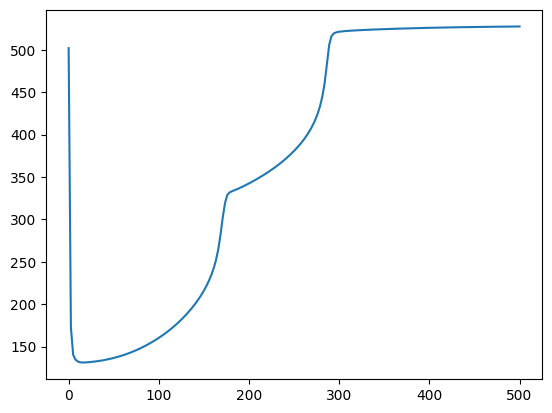

In [7]:
m_ = np.array([x.dot(vols) for x in aux_ts]);
plt.plot(t, m_)

# Smaller tissue.

Text(0.5, 1.01, '$t_{final}=$200  P=1.0,  T=1.0,  $\\rho_0$=0.01,  δ=0.01,  S0=0.0,  μ=1,  η=1,  $n_{ht}$=2,  $\\tau_{\\infty PD}$=125,  $n_{hPD}$=4,  $\\theta_{PD}$=0.5,  $\\tau_{\\infty PIN}$=inf,  $n_{hPIN}$=2,  $\\theta_{PIN}$=0.5,  $\\rho_{PD}$=2.11,  $\\rho_{PIN}$=0.21')

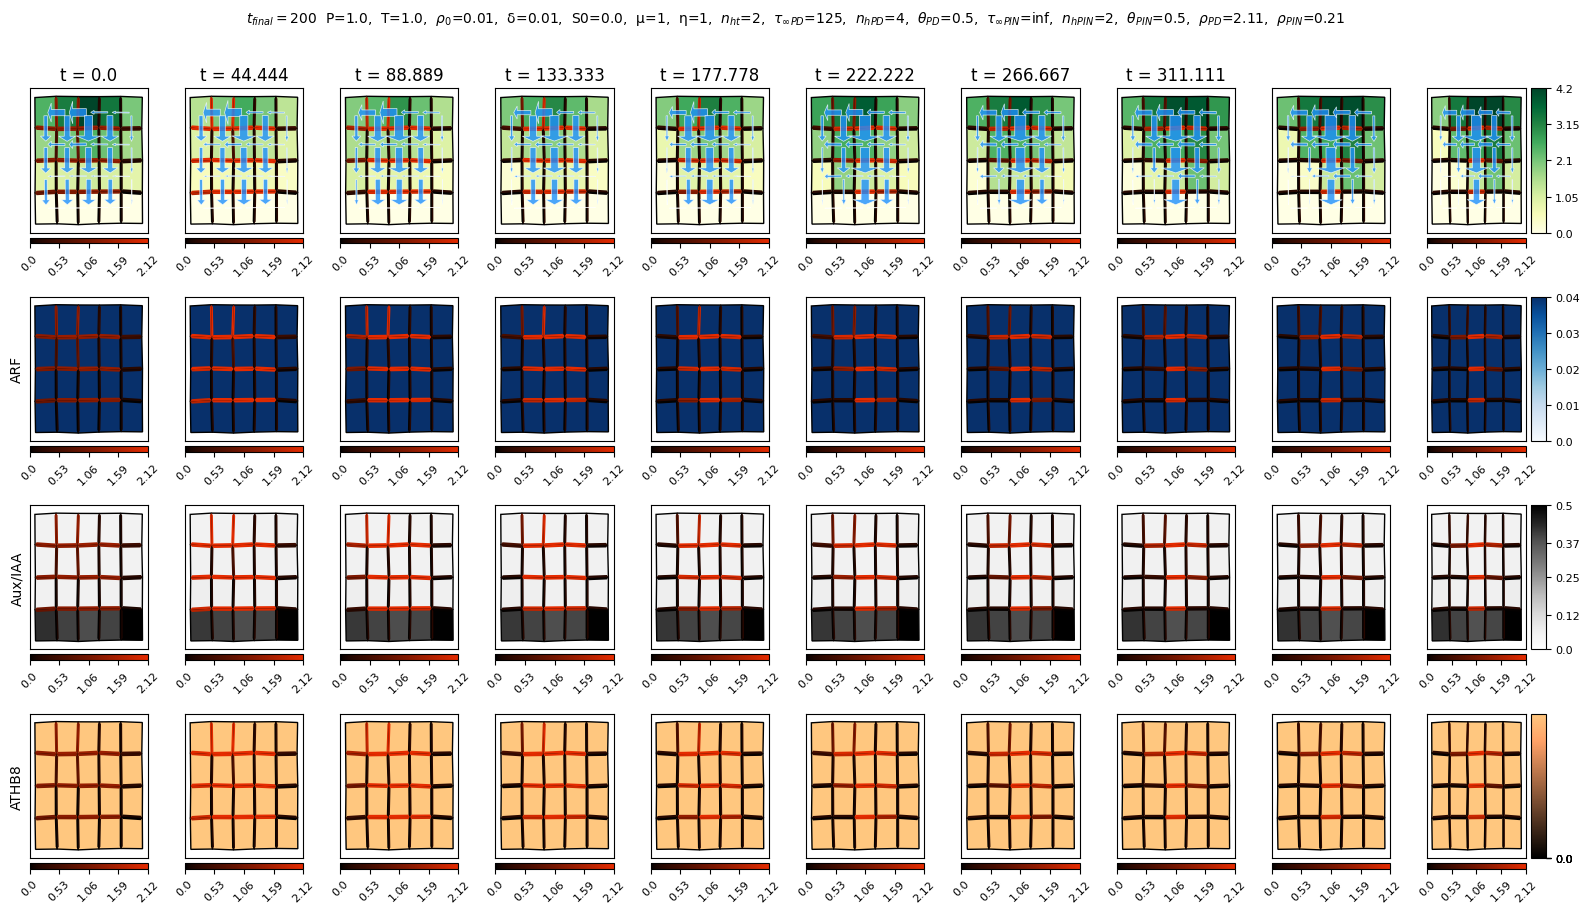

In [8]:

# Set parameters and run solve_ivp
pars = pars_default # Reset to default 
### Uncomment and change for manual exploration
P= 1.0     # permeability, 
T= 1.0      # nominal active transport rate
δ= 0.01    # degradation rate for auxin
S0 = 0.0  # default production rate (without YUCCA), expected low
μ = 1   # degradation rate for plasmodesmata
η = 1   # degradation rate for PIN
nht = 2     # Hill exponent, for the tau dependent PD closure

rho_0 = 1e-2  #0.01 # background/minimal diffusivity, added to walls as a constant

tau_infPD = 125 #0.01#0.1#np.inf#125 
rhoPD = 2*μ* np.max(wAdj)       # Amplitude for the Hill function; chosen to match the initial wall sizes, normalized with μ to make equilibrium ~1.
nhPD = 4                    # Hill exponent, for the plasmodesmata rate
thPD = .5 # 0.5               # Hill threshold, for the plasmodesmata rate. If set to np.inf, a power function φ^n  will be used instead of Hill.

tau_infPIN = np.inf
rhoPIN = 0.2*η* np.max(wAdj)      # Amplitude for the Hill function; chosen to match the initial wall sizes, normalized with η to make equilibrium ~1.
nhPIN = 2                   # Hill exponent, for the PIN rate
thPIN= 0.5 # 0.5               # Hill threshold, for the PIN rate. If set to np.inf, a power function φ^n  will be used instead of Hill.

pars = P, T, rho_0, δ, S0, μ, η, nht, tau_infPD,  nhPD, thPD, tau_infPIN, nhPIN, thPIN, rhoPD, rhoPIN


#Initial condition 
adj_dic_00_p = dict( zip(edges_p, list(zip( np.zeros(len(edges_p)), np.zeros(len(edges_p))  ) ) ) )
Lap_00_p = laplace_matrix( adj_mat(adj_dic_00_p) )
AP_00_p =  np.concatenate( (np.array([ratio*Lap_00_p[i,j] for i,j in edges_p]), np.zeros(len(edges_p)), np.zeros(len(edges_p)) ) )

# Some Defaults for source and sinks:
S_vals = 1.*np.array([.01, .8, 2., .8, .01])  ## The left column as a high production rate in the middle.


prod_p = S0*np.ones(n_p) ## A centre peak on top row, the rest at S0
prod_p[ny_p-1::ny_p] = S_vals


R_vals_p = [100.0]*nx_p
#degr_default = np.hstack( ([δ]*(n-len(R_vals)), R_vals) )  ## A rate as in R_vals on right column, rest at default (=δ)
degr_p = δ*np.ones(n_p)  ## A rate as in R_vals on bottom row, rest at default (=δ)
degr_p[::ny_p] = R_vals_p


# Time-stepping data 
tau_final_p = 200
t_p = np.linspace(0,2.0*tau_final_p,100)

args_p =  (pars, edges_p, prod_p, degr_p, vols_p,)

### QSS-like reduced model
AP_pre_p = solve_ivp(qss_dyn, t_span=[0, 1],y0= AP_00_p, method='RK45', args=args_p)
AP_01_p = AP_pre_p.y[:,-1]

AP_sol_p = solve_ivp(qss_dyn, t_span=[t_p[0],t_p[-1]], t_eval=t_p, y0= AP_01_p, method='RK45', args=args_p)
PD_y_p, PINup_y_p, PINdown_y_p = AP_sol_p.y[:m_p,:], AP_sol_p.y[m_p:2*m_p,:], AP_sol_p.y[2*m_p:,:]

### Full model including auxin dynamics
# APa_00 =  np.concatenate( (  AP_sol.y[:,-1], np.zeros(n) ) )
# APfull_pre = solve_ivp(full_dyn, t_span=[0, 10],y0= APa_00, method='LSODA', args=args)
# APa_01 = APfull_pre.y[:,-1]
# APfull_sol = solve_ivp(full_dyn, t_span=[t[0],t[-1]], t_eval=t, y0= APa_01, method='BDF', args=args)
# PD_full_y, PINup_full_y, PINdown_full_y, a_full_y = APfull_sol.y[:m,:], APfull_sol.y[m:2*m,:], APfull_sol.y[2*m:3*m,:], APfull_sol.y[3*m:,:]

# # Extract adjacency matrix weights and display time series (some snapshots)
# Λ_y_p = [adj_mat( dict( zip(edges_p, list( zip( PD_y_p[:,step]+PINup_y_p[:,step], PD_y_p[:,step]+PINdown_y_p[:,step] ) ) ) ), n=n_p ) for step in range(len(t_p))]
# #aux_ts = [ walls_to_aux(Λ_y[step] ) for  step in range(len(t))]
# aux_ts_p = [ walls_to_aux(Λ_y_p[step], prod=prod_p, degr=degr_p, vols=vols_p) for  step in range(len(t_p))]

#############################################################################################################################################
## Visual representation:

# nb_snapshots = 10
# fig, ax = plt.subplots(nrows=1, ncols=nb_snapshots, figsize=(16,4),); # Create a figure
# for ii, step in enumerate( map(int, np.linspace(0,len(t_p)-1, nb_snapshots) )):
#     title = 't = '+str(np.round((AP_sol_p.t)[step], 3) ) 
#     plot_geom(ax[ii], cells=cells_p, cvals= aux_ts_p[step], wvals= Λ_y_p[step], cbar=1*(ii==nb_snapshots-1), wbar= 1, ccol=mcm['YlGn'], cvalmax=np.max( aux_ts_p ) , 
#                 wvalmax=np.max(AP_sol_p.y), wcol=mcm['cet_linear_ternary_red_0_50_c52'], alpha=.5+.5*(t_p[step]<=tau_final) , nx=nx_p, ny=ny_p, X=X_p, Y=Y_p )
#     if t[step]<tau_final_p : ax[ii].set_title(title)
#     elif t[step]==tau_final_p : ax[ii].set_title(title, color='crimson')
#     else: ax[ii].set_title(title, color= 'silver')
#         # We also include a representation of auxin fluxes 
#     plot_graph(ax[ii], Flx=make_flux(aux_ts_p[step], AP_sol_p.y[:,step], P=P, T=T, edges=edges_p), width=0.7, alpha=.8, fcol='dodgerblue', ec='white', edges=edges_p, centroids=centroids_p)
# fig.suptitle(r'$t_{final}=$'+str(tau_final_p)+'  '+',  '.join([parnames[i]+'='+str(np.round(pars[i],2)) for i in range(len(pars)) ]), y=1.1, fontsize=10)
# #fig.savefig("PD_only.png", dpi=300, bbox_inches='tight')
# #fig.savefig("PIN_only.png", dpi=300, bbox_inches='tight')

# Extract adjacency matrix weights and display time series (some snapshots)
Λ_y_p = [adj_mat( dict( zip(edges_p, list( zip( PD_y_p[:,step]+PINup_y_p[:,step], PD_y_p[:,step]+PINdown_y_p[:,step] ) ) ) ), n=n_p ) for step in range(len(t_p))]
#aux_ts = [ walls_to_aux(Λ_y[step] ) for  step in range(len(t))]
aux_ts_p = [ walls_to_aux(Λ_y_p[step], prod=prod_p, degr=degr_p, vols=vols_p) for  step in range(len(t_p))]

nb_snapshots = 10
#aux_ts_p = [walls_to_aux(Λ_y_p[step], prod=prod_p, degr=degr_p, vols=vols_p) for step in map(int, np.linspace(0,len(t_p)-1, nb_snapshots) )]
A0, I0, B0 = .2*np.ones(n_p), .2*np.ones(n_p), .2*np.ones(n_p)
X0 = np.concatenate( (A0, I0, B0) ) + .01*np.random.uniform(-1,1,3*n_p) # 


## Memo: ## H = lambda x,y, kx=1,ky=1,k0=1, nI=2, nA=2: kx*(x**nA)/( kx*(x**nA) + ky*(x**nA)*(y**nI) + k0 )
## pars_now has kAx, kAy, nAA, kIx, kIy, nAI, kBx, kBy, nAR, nI, k_b, aux_in_th, dx 
pars_now = [10,15,4, 1,1,4, 10,.1,4, 4, 0.04, .2, .8] #[10,10,1, 1,1,1, 10,.1,1, 4,2, .01, .1, 1]  #[10,1,.1, .1,0,1, 1,1,1, 4, 4]#[1,1,1, 1,1,1, .1,1,1, 2, 2]
Z_ts = [ aux_to_ATHB8_ss(aux, X0=X0, pars = pars_now, n=n_p) for aux in aux_ts_p]


fig, ax = plt.subplots(nrows=4, ncols=nb_snapshots, figsize=(16,9), tight_layout=True); # Create a figure
colorings = ['Blues', 'Greys', 'copper']
rng_varnames = ['ARF', 'Aux/IAA', 'ATHB8']
for ii, step in enumerate( map(int, np.linspace(0,len(t_p)-1, nb_snapshots) )):
    title = 't = '+str(np.round((AP_sol_p.t)[step], 3) ) 
    alpha = 1 ## .5+.5*(t_p[step]<=tau_final)
    plot_geom(ax[0,ii], cells=cells_p, cvals= aux_ts_p[step], wvals= Λ_y_p[step], cbar=1*(ii==nb_snapshots-1), wbar= 1, ccol=mcm['YlGn'], cvalmax=np.max( aux_ts_p ) , 
                wvalmax=np.max(AP_sol_p.y), wcol=mcm['cet_linear_ternary_red_0_50_c52'], alpha=alpha , nx=nx_p, ny=ny_p, X=X_p, Y=Y_p )
    plot_graph(ax[0,ii], Flx=make_flux(aux_ts_p[step], AP_sol_p.y[:,step], P=P, T=T, edges=edges_p), width=0.7, alpha=.8, fcol='dodgerblue', ec='white', edges=edges_p, centroids=centroids_p)
    if t[step]<tau_final_p : ax[0,ii].set_title(title)
    for i_var in range(3):
        Z = Z_ts[ii]
        #if i_var == 0: title = 't = '+str(np.round((AP_sol_p.t)[step], 3) ) 
        #else: title =  None
        plot_geom(ax[i_var+1,ii], cells= cells_p, cvals= Z[i_var*n_p:(i_var+1)*n_p], wvals= Λ_y_p[step], cbar=1*(ii==nb_snapshots-1), wbar= 1, ccol=mcm[colorings[i_var]], 
                  cvalmax= max( list(map(np.max, [Z[i_var*n_p:(i_var+1)*n_p] for Z in Z_ts])) ), wvalmax=np.max(AP_sol_p.y), wcol=mcm['cet_linear_ternary_red_0_50_c52'], 
                  alpha=alpha,nx=nx_p, ny=ny_p, X=X_p, Y=Y_p )
        #elif t_p[step]==tau_final_p : ax[i_var, ii].set_title(title, color='crimson')
        #else: ax[i_var+1,ii].set_title(title, color= 'silver')
            # We also include a representation of auxin fluxes 
        #plot_graph(ax[i_var,ii], Flx=make_flux(aux_ts[step,:], AP_sol.y[:,step]), width=0.7, alpha=.8, fcol='yellow', ec='black',  edges=edges_p, centroids=centroids_p)
        if ii==0:  ax[i_var+1, ii].set_ylabel(rng_varnames[i_var])
fig.suptitle(r'$t_{final}=$'+str(tau_final_p)+'  '+',  '.join([parnames[i]+'='+str(np.round(pars[i],2)) for i in range(len(pars)) ]), y=1.01, fontsize=10)

##

In [9]:
# mass_p = np.array([x.dot(vols_p) for x in aux_ts_p]);
# plt.plot(t_p, mass_p)

In [10]:
(prod_p * vols_p).dot(1/degr_p), prod_p.dot(vols_p)

(np.float64(723.327719629774), np.float64(7.23327719629774))

Text(0.5, 1.01, 'kAx, kAy, nAA, kIx, kIy, nAI, kBx, kBy, nAR, nI, k_b, aux_in_th, dx = [10, 10, 2, 10, 1, 4, 10, 1, 2, 4, 0.01, 0.1, 0.8]')

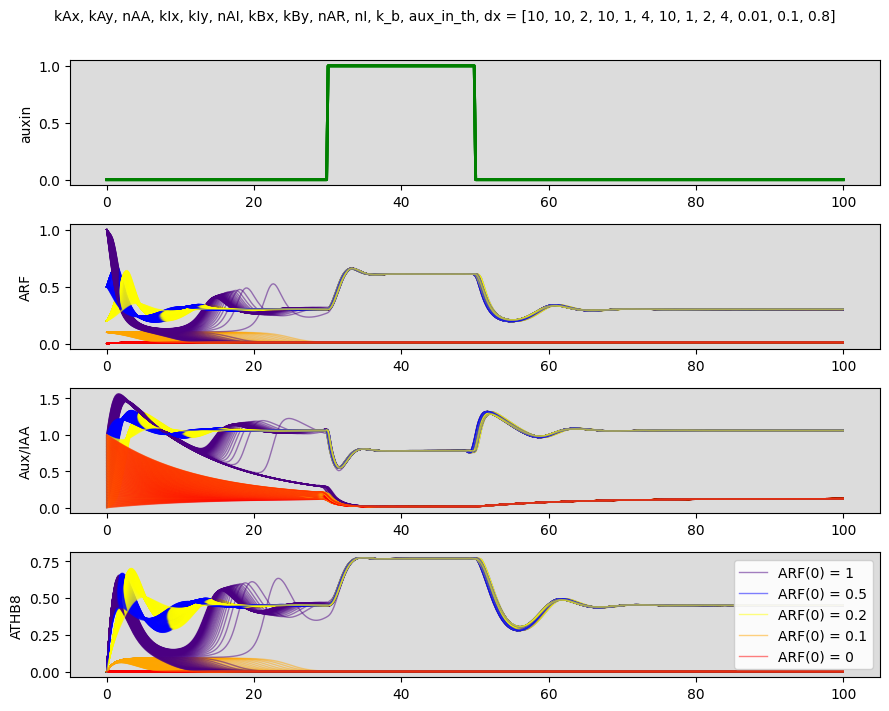

In [11]:
## Memo: ## H = lambda x,y, kx=1,ky=1,k0=1, nI=2, nA=2: kx*(x**nA)/( kx*(x**nA) + ky*(x**nA)*(y**nI) + k0 )
## pars_now has kAx, kAy, nAA, kIx, kIy, nAI, kBx, kBy, nAR, nI, k_b, aux_in_th, dx 

fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(9,7), tight_layout=True); # Create a figure
#A0, I0, B0 = 1*np.ones(n_p), 1*np.ones(n_p), 0*np.ones(n_p)
nb = 100
t0, t1 = 30, 50
t_eval = np.linspace(0,100,500)
#aux_stair = lambda t:  [np.sum( [ .5*aux_in(t,1, 0, t_0, np.inf)  for t_0 in range(30,110,20)] ) - 2*aux_in(t,1, 0, 110, np.inf) ]
aux_in_now = lambda t: 1*aux_in(t,1, 0, t0, t1)
pars_now = [10,10,2,  # kAx, kAy, nAA
            10,1,4,  # kIx, kIy, nAI
            10,1,2,  # kBx, kBy, nAR
            4,       # nI
            0.01,     # k_b
            .1,.8]   # aux_in_th, dx

for cntr in range(nb):
    #X0 = np.concatenate( (A0+np.random.uniform(-.1,.1,n_p), I0, B0) ) 
    #X0 = [np.random.uniform(0,1) , np.random.uniform(0,1) , np.random.uniform(0,1) ]
    ic = 0
    for (x0arf,c) in [ (1,'indigo'), (.5,'blue'), (.2,'yellow'), (.1, 'orange'), (0,'red')]:
        X0 = [x0arf, cntr/(nb-1.), 0]
        
        #Sol=solve_ivp(RGN_ode, t_span=[0, 100],y0= X0, method='RK45', args= ( [1,1,.1, 1,1,.1, .1,1,.1], lambda t: .1*np.ones(n), ))
        #Sol=solve_ivp(RGN_ode, t_span=[0, 100],y0= X0, method='RK45', args= ( pars_now, lambda t:  aux_ts_p[4], n_p) ) 
        #Sol=solve_ivp(RGN_ode, t_span=[0, 100],y0= X0, method='RK45', args= ( pars_now, lambda t: 100*aux_in(t,n_p, .5), n_p) ) 

        #Sol=solve_ivp(RGN_ode, t_span=[t_eval[0], t_eval[-1]],y0= X0, method='RK45', args= ( pars_now, aux_stair, 1, ), t_eval=t_eval) 
        Sol=solve_ivp(RGN_ode, t_span=[0, 100],y0= X0, method='RK45', args= ( pars_now, aux_in_now ,1, ) , t_eval=np.linspace(0,100,500)) 

        #colorings = ['Blues', 'Reds', 'Purples']
        if cntr ==0: 
            #ax[0].plot(Sol.t, np.array(list(map(aux_stair, Sol.t))).flatten() , c='lime',lw=2)
            ax[0].plot(Sol.t, aux_in_now(Sol.t), c='green',lw=2)
            ax[0].set_facecolor( 'gainsboro')
            ax[0].set_ylabel('auxin')
        #print( '['+cntr*'-'+(nb-cntr-1)*' '+']  ---   Xs~', np.round(Sol.y[:,-1], 3) )
        for k in range(1,4):
            #[ax[k].plot(Sol.t, Sol.y[k*n_p+i,:],c= mcm[colorings[k]](aux_ts_p[4][i]), lw=2, alpha=.9) for i in range(n_p)];
            if cntr == 0: 
                lab =  'ARF(0) = '+str([1,.5,.2,.1,0][ic])
            else: lab = None
            ax[k].plot(Sol.t, Sol.y[k-1,:], c=c, lw=1, alpha=0.5, label=lab)#, c='k')
            ax[k].set_ylabel(rng_varnames[k-1])
            ax[k].set_facecolor( 'gainsboro')
        ax[k].legend(fancybox=True, framealpha=0.9, loc='center right')
        ic += 1
fig.suptitle('kAx, kAy, nAA, kIx, kIy, nAI, kBx, kBy, nAR, nI, k_b, aux_in_th, dx = '+str(pars_now), y=1.01, fontsize=10)

# Candidates with k_b =0.01 (on both ARF and IAA (within H numerator))
# 10,10,2,  # kAx, kAy, nAA
# 1,10,4,  # kIx, kIy, nAI
#
# 10,10,2,  # kAx, kAy, nAA
# 10,1,4,  # kIx, kIy, nAI
#
# 10,10,2,  # kAx, kAy, nAA
# 1,1,4,  # kIx, kIy, nAI
#
# 10,1,2,  # kAx, kAy, nAA
# 10,1,4,  # kIx, kIy, nAI

#### Below one defines a function that will be used to generate animations from a computed time series of PD status

In [12]:
def PD_mov( frame, ax, PD_series):   # This function creates frame number frame
    ax.cla()  ; # Clear the previous frame
    PD = PD_series.y[:,frame]
    aux = walls_to_aux(PD)
    PDmat = np.zeros( (n,n) )
    for k,(i,j) in enumerate(edges): 
        PDmat[i,j] = PD[k]
        PDmat[j,i] = PD[k]
    title = 't = '+str(np.round((PD_series.t)[frame], 3) ) 
    if frame==0:
        plot_geom(ax,cvals= aux, wvals=PDmat, cbar=1, wbar=1, ccol=mcm['YlGn'], cvalmax=np.max( list(map(walls_to_aux, PD_series.y)) ), 
              wvalmax=np.max(PD_series.y), wcol=mcm['cet_linear_ternary_red_0_50_c52'] , title = title)
    else:
        plot_geom(ax,cvals= aux, wvals=PDmat, cbar=0, wbar=0, ccol=mcm['YlGn'], cvalmax=np.max( list(map(walls_to_aux, PD_series.y)) ), 
              wvalmax=np.max(PD_series.y), wcol=mcm['cet_linear_ternary_red_0_50_c52'] , title = title)
    # We also include a representation of auxin fluxes 
    plot_graph(ax, a=aux , Flx=PD, width=0.7, alpha=.8, fcol='dodgerblue', ec='white')
  

In [13]:
PD_fullpre_y, PINup_fullpre_y,PINdown_fullpre_y, a_fullpre_y = APfull_pre.y[:m,:], APfull_pre.y[m:2*m,:], APfull_pre.y[2*m:3*m,:], APfull_pre.y[3*m:,:]
Λpre_y = [adj_mat( dict( zip(edges, list( zip( PD_fullpre_y[:,step]+PINup_fullpre_y[:,step], PD_fullpre_y[:,step]+PINdown_fullpre_y[:,step]) ) ) ) ) for step in range(APfull_pre.y.shape[1])]


NameError: name 'APfull_pre' is not defined

In [ ]:

# nb_snapshots = 7
# fig, ax = plt.subplots(nrows=1, ncols=nb_snapshots, figsize=(14,4),); # Create a figure
# for ii, step in enumerate( map(int, np.linspace(0,APfull_pre.y.shape[1]-1, nb_snapshots) )):
#     aux = a_fullpre_y[:,step]

#     title = 't = '+str(np.round((APfull_pre.t)[step], 3) ) 
#     plot_geom(ax[ii], cvals= aux, wvals= Λpre_y[step], cbar=1*(ii==nb_snapshots-1), wbar= 1, ccol=mcm['YlGn'], cvalmax= np.max(APfull_pre.y[3*m:,:]), 
#                 wvalmax=np.max(APfull_pre.y[:3*m,:]), wcol=mcm['cet_linear_ternary_red_0_50_c52'] )
#     ax[ii].set_title(title)

#         # We also include a representation of auxin fluxes 
#     plot_graph(ax[ii], Flx=make_flux(aux, APfull_pre.y[:,step]), width=0.7, alpha=.8, fcol='dodgerblue', ec='white')
# fig.suptitle('ξ='+str(ξ)+r' $,  \tau_{final}=$'+str(tau_final)+'  '+',  '.join([parnames[i]+'='+str(np.round(pars[i],2)) for i in range(len(pars)) ]), y=1.1, fontsize=10)
# #fig.savefig("PD_only.png", dpi=300, bbox_inches='tight')
# #fig.savefig("PIN_only.png", dpi=300, bbox_inches='tight')

In [ ]:
#walls_to_aux(Λ_y[0]), walls_to_aux(Λ_y[1]), walls_to_aux(Λ_y[step])
plt.plot( [np.mean(walls_to_aux(Λ_y[i])) for i in range(len(t)) ] , '.', [np.max(walls_to_aux(Λ_y[i])) for i in range(len(t)) ], 'x')

----
----
----

Previous exploratory anaysis

In [ ]:
#PD_target_vec = np.array( [1 if k in [9,11,13,15, 18,20,22,24, 27,29,31,33] else 0 for k in range(m) ])
on_walls_1 = [13,15,17,19,21,23, 26,28,30,32,34,36, 39,41,43,45,47,49 ]
off_walls_1 = [2,3,4,5,6,7,8,9,11, 42,44,53,46,54,48,55,50,56]
hi, mi, lo = 1, .5, 0.3
PD_target_vec_1 = np.array( [hi if k in on_walls_1 else mi if k in off_walls_1 else lo for k in range(m) ])
PD_target_1 = adj_mat( dict(zip(edges, list(zip([PD_target_vec_1[k] for k in range(len(edges))],
                                                [PD_target_vec_1[k] for k in range(len(edges))])) )) )

on_walls_2 = [13,15,17,19,21,23, 26,28,30,32,34,36, 39,41,43,45,47,49 ]
off_walls_2 = [0,1,2,3,4,5,6,7,8,9,10,11,14,27,40,12,25,38,51,42,44,53,46,54,48,55,50,52,56,57]
PD_target_vec_2 = np.array( [hi if k in on_walls_2 else mi if k in off_walls_2 else lo for k in range(m) ])
PD_target_2 = adj_mat( dict(zip(edges, list(zip([PD_target_vec_2[k] for k in range(len(edges))],
                                                [PD_target_vec_2[k] for k in range(len(edges))])) )) )

on_walls_3 = [1,14, 27, 40,  13,15,17,19,21,23, 26,28,30,32,34,36, 39,41,43,45,47,49 ]
off_walls_3 = [0,1,2,3,4,5,6,7,8,9,10,11,14,27,40,12,25,38,51,42,44,53,46,54,48,55,50,52,56,57]
PD_target_vec_3 = np.array( [hi if k in on_walls_3 else mi if k in off_walls_3 else lo for k in range(m) ])
PD_target_3 = adj_mat( dict(zip(edges, list(zip([PD_target_vec_3[k] for k in range(len(edges))],
                                                [PD_target_vec_3[k] for k in range(len(edges))])) )) )


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4),); # Create a figure
#plot_geom(ax,cvals=degr_default, cbar=0, wbar=0, ccol=mcm['Greys'])
#plot_geom(ax,cvals= np.ones((n,)), cbar=0, wbar=0, ccol=mcm['Greys_r'])
plot_geom(ax[0],cvals= np.ones((n,)), wvals=PD_target_1, cbar=0, wbar=0, ccol=mcm['Greys_r'], wcol=mcm['RdYlGn'])
plot_geom(ax[1],cvals= np.ones((n,)), wvals=PD_target_2, cbar=0, wbar=0, ccol=mcm['Greys_r'], wcol=mcm['RdYlGn'])
plot_geom(ax[2],cvals= np.ones((n,)), wvals=PD_target_3, cbar=0, wbar=0, ccol=mcm['Greys_r'], wcol=mcm['RdYlGn'])
for i in range(n): 
    ax[0].text(centroids[i][0], centroids[i][1], str(i), c='k', fontsize=6)
    ax[1].text(centroids[i][0], centroids[i][1], str(i), c='k', fontsize=6)
    ax[2].text(centroids[i][0], centroids[i][1], str(i), c='k', fontsize=6)
for k,(i,j) in  enumerate(edges): 
    ax[0].text( (centroids[i][0]+centroids[j][0])/2+.05, (centroids[i][1]+centroids[j][1])/2+.05, str(k), c='blue', fontsize=8)
    ax[1].text( (centroids[i][0]+centroids[j][0])/2+.05, (centroids[i][1]+centroids[j][1])/2+.05, str(k), c='blue', fontsize=8)
    ax[2].text( (centroids[i][0]+centroids[j][0])/2+.05, (centroids[i][1]+centroids[j][1])/2+.05, str(k), c='blue', fontsize=8)
#plot_graph(ax, a=aux , Adj=PD, width=0.7, alpha=.8, fcol='dodgerblue', ec='white')
ax[0].set_title("Pattern 1")
ax[1].set_title("Pattern 2")
ax[2].set_title("Pattern 3")

In [ ]:

def fitness(p, num=1):
    # return (np.sum( [(PD[i]-1)**2 for i in [13,15,17,19,21,23, 26,28,30,32,34,36, 39,41,43,45,47,49 ] ) +  \
    #                    np.sum( [PD[i]**2 for i in [0,2,3,4,5,6,7,8,9,11, 42,52,44,53,46,54,48,55,50,56] ] ))**1/2.
    PD_series = solve_ivp( plasmo_dyn, t_span=[t[0],t[-1]], t_eval=t, y0=[ratio*Lap[i,j] for i,j in edges], args=( p, edges, None, None, ),  method='LSODA')
    PD = PD_series.y[:,-1]
    if num==1:
        return (np.sum( [(PD[i]-1)**2 for i in on_walls_1] ) + np.sum( [PD[i]**2 for i in off_walls_1 ] ))**1/2.
    elif num==2:
        return (np.sum( [(PD[i]-1)**2 for i in on_walls_2] ) + np.sum( [PD[i]**2 for i in off_walls_2 ] ))**1/2.

In [ ]:

tmp1 = minimize( lambda p: fitness( p,1), pars_sample[II[0][0]] , bounds=[(0,None)]*7)

In [ ]:
#tmp2 = lsq( lambda p: fitness( p,2), pars_sample[II[1][0]] )
tmp2 = minimize( lambda p: fitness( p,2), pars_sample[II[1][0]] , bounds=[(0,None)]*7)

In [ ]:
tmp1, tmp2

In [ ]:
# gtmp1_, gtmp2_ = [],[]
# for method in [direct, differential_evolution, shgo, dual_annealing]:
#     gtmp1_.append( method(lambda p: fitness( p,1), bounds= par_bounds ) )
#     gtmp2_.append( method(lambda p: fitness( p,2), bounds= par_bounds ) )
## NB: The above took 794m8.9s (>13h)

# fileObj = open('globals_patt1.obj', 'wb')  
# pickle.dump(gtmp1_,fileObj)
# fileObj.close()
# fileObj = open('globals_patt2.obj', 'wb')  
# pickle.dump(gtmp2_,fileObj)
# fileObj.close()

fileObj = open('globals_patt1.obj', 'rb') 
gtmp1_ = pickle.load(fileObj)
fileObj.close()
fileObj = open('globals_patt2.obj', 'rb') 
gtmp2_ = pickle.load(fileObj)
fileObj.close()


In [ ]:
meths= ['direct', 'differential_evolution', 'shgo', 'dual_annealing']
methnames = ['direct', 'diff. evol.', 'shgo', 'dual\n annealing']
for i in range(4):
    print('Pattern 1,',meths[i],'success =', gtmp1_[i].success, 'x value =', np.round(gtmp1_[i].x, 2), 'f value=',gtmp1_[i].fun, '\n')
    print('Pattern 2,',meths[i],'success =', gtmp2_[i].success, 'x value =', np.round(gtmp2_[i].x, 2), 'f value=',gtmp2_[i].fun, '\n')

In [ ]:
# fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(20,9), tight_layout=True); # Create a figure
# plt.rc("hatch", linewidth=3)
PARS = np.array(pars_sample)
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20,9), tight_layout=True); # Create a figure
j = 0 
cutoff=2000
for i,ax in enumerate(axs.flat): 
    if  i<7: ##not i in [4,8,9]:
        ax.plot(np.arange(4)-.1, [g.x[j] for g in gtmp1_], 'Pb', ms=10, label='Pattern 1' if i==0 else None )
        # ax.legend(fontsize=14)
        ax.plot(np.arange(4)+.1, [g.x[j] for g in gtmp2_], 'Pg', ms=10, label='Pattern 2' if i==0 else None  )
        vp=ax.violinplot(PARS[II[0]][:cutoff,j],positions=[4-.2], showmeans=True)
        for body in vp['bodies']:
            body.set_color('blue')
            body.set_edgecolor('blue')
        for partname in ('cbars','cmins','cmaxes','cmeans'):
            vprt = vp[partname]
            vprt.set_edgecolor('blue')
            vprt.set_linewidth(3)

        vp=ax.violinplot(PARS[II[1]][:cutoff,j],positions=[4+.2], showmeans=True)
        for body in vp['bodies']:
            body.set_facecolor('green')
            body.set_edgecolor('green')
        for partname in ('cbars','cmins','cmaxes','cmeans'):
            vprt = vp[partname]
            vprt.set_edgecolor('green')
            vprt.set_linewidth(3)
        ax.set_title(parnames[j], fontsize=16)
        ax.set_xticks(range(5),labels= methnames+['grid'])
        ax.grid(1)
        if i==0: ax.legend(fontsize=14)
        j+=1
    elif i==7:# i==8:
        # ax.barh(np.arange(4)-.1, [np.log10(g.fun) for g in gtmp1_], height=.2, color='b' )#, 'ob' , ms=10, label='Pattern 1' if i==0 else None )
        # ax.barh(np.arange(4)+.1, [np.log10(g.fun) for g in gtmp2_], height=.2, color='g' )#, 'og' , ms=10, label='Pattern 2' if i==0 else None )
        ax.plot([np.log10(g.fun) for g in gtmp1_], np.arange(4)-.1, 'P', color='b', ms=10) #label='Pattern 1' if i==0 else None )
        ax.plot([np.log10(g.fun) for g in gtmp2_], np.arange(4)+.1, 'P', color='g', ms=10) #label='Pattern 2' if i==0 else None )
        #counts, bins = np.histogram( np.array(dist_to_target)[0,II[0]][:cutoff])
        ax.scatter( np.log10(np.array(dist_to_target)[0,II[0]][:cutoff]), [4-.1]*cutoff , color='b', marker='s', alpha=.01, s=100)
        ax.scatter( np.log10(np.array(dist_to_target)[1,II[1]][:cutoff]), [4+.1]*cutoff , color='g', marker='s', alpha=.01, s=100)
        ax.set_title('Fitness value (log(.))', fontsize=16)
        ax.set_yticks(np.arange(5), labels=methnames+['grid'])

        ax.invert_yaxis()  # labels read top-to-bottom
        ax.grid(1)
# ax = plt.subplot(2,5,(5,10))
# ax.violinplot(PARS[II[0][:2000]])

plt.savefig('scan_summary.png', dpi=300)

In [ ]:
# fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(20,9), tight_layout=True); # Create a figure
# plt.rc("hatch", linewidth=3)
# j = 0 
# for i,ax in enumerate(axs.flat): 
#     if not i in [4,8,9]:
#         ax.bar(np.arange(4)-.2, [g.x[j] for g in gtmp1_], width=.4, color=['C'+str(k) for k in range(7)],label=methnames)
#         #if i==0: ax.legend(fontsize=14)
#         ax.bar(np.arange(4)+.2, [g.x[j] for g in gtmp2_], hatch='//', ec='w', width=.4, color=['C'+str(k) for k in range(7)])
#         ax.set_title(parnames[j], fontsize=12)
#         ax.set_xticks(range(4),labels=methnames)
#         j+=1
#     elif i==8:
#         ax.bar(np.arange(4)-.1, [g.fun for g in gtmp1_], width=.2, color=['C'+str(k) for k in range(7)],label=meths)
#         ax.bar(np.arange(4)+.1, [g.fun for g in gtmp2_], hatch='//', ec='w',  width=.2, color=['C'+str(k) for k in range(7)])
#         ax.set_title('Fitness value', fontsize=16)
#         ax.set_xticks(range(4),labels=methnames)
# ax = plt.subplot(2,5,(5,10))
# #ax.hist()


In [ ]:
gtmp1 = direct(lambda p: fitness( p,1), bounds= par_bounds )

In [ ]:
gtmp2 = direct(lambda p: fitness( p,2), bounds= par_bounds )

In [ ]:
gtmp1, gtmp2

In [ ]:
PARS[II[0][0]]##.shape ##, [fitness( select_pars[PARS[II[0][i]]],1) for i in range(10)]

In [ ]:
nbp= 5
nbt = 5
PD_time_samples = np.zeros((2,nbp, m, nbt))  # Reminder: m is the number of edge (= PD locus)
t_smp = np.linspace(t[0]+.1*(t[-1]-t[0]), t[-1], nbt)
t_offset = 0 #7170
small_pars_sample = [ np.array([g.x for g in gtmp1_]+[PARS[II[0][0]] ]) , np.array([g.x for g in gtmp2_] + [PARS[II[1][0]]] ) ]
ratio = 1
for k in range(nbp-1):
    for i in range(2):
        pars_1 = small_pars_sample[i][k]
    #     pars_1 = pars_sample[II[i][t_offset+k]]
        #δ, S0, μ, tau_inf, nht, nh, th = pars_1
        # Use S0 and δ
        # prod_pars1 = S0*np.ones(n) ## A centre peak on top row, the rest at S0
        # prod_pars1[ny-1::ny] = S_vals
        # degr_pars1 = δ*np.ones(n)  ## A rate as in R_vals on bottom row, rest at default (=δ)
        # degr_pars1[::ny] = R_vals
        PD_time_samples[i,k,:,:] = solve_ivp( plasmo_dyn, t_span=[t[0],t[-1]], t_eval=t_smp, y0=[ratio*Lap[i,j] for i,j in edges], args=( pars_1, edges, ),  method='LSODA').y
        



In [ ]:

fig, axs = plt.subplots(nrows=nbp, ncols=nbt, figsize=(12,20), tight_layout=True); # Create a figure
for i, j in it.product(range(nbp), range(nbt)):
    
    PD_instance =  adj_mat( dict(zip(edges, PD_time_samples[0,i,:,j] )) )
    aux = PD_to_aux(PD_time_samples[0,i,:,j])
    plot_geom(axs[i,j],cvals= aux, wvals=PD_instance, cbar=0, wbar=0, ccol=mcm['YlGn'], wcol=mcm['cet_linear_ternary_red_0_50_c52'],  wvalmax=np.max(PD_instance))
    axs[i,j].set_xlabel("t= "+str(t_smp[j]))
fig.suptitle(t="Pattern 1", x=0.5,y=1.01)

In [ ]:

fig, axs = plt.subplots(nrows=nbp, ncols=nbt, figsize=(12,20), tight_layout=True); # Create a figure
for i, j in it.product(range(nbp), range(nbt)):
    
    PD_instance =  adj_mat( dict(zip(edges, PD_time_samples[1,i,:,j] )) )
    aux = PD_to_aux(PD_time_samples[1,i,:,j])
    plot_geom(axs[i,j],cvals= aux, wvals=PD_instance, cbar=0, wbar=0, ccol=mcm['YlGn'], wcol=mcm['cet_linear_ternary_red_0_50_c52'],  wvalmax=np.max(PD_instance))
    axs[i,j].set_xlabel("t= "+str(t_smp[j]))

In [ ]:

def iws(PD):
    return ( np.sum( [PD[i]**2 for i in [12, 14, 16, 21, 23, 25] ] ))**1/2.

inner_walls_dict = dict( (pars_1, iws(select_pars[pars_1])) for pars_1 in select_pars.keys() )
inner_walls = np.array( list(inner_walls_dict.values()) )

In [ ]:
I = np.argsort(dist_to_target)
# print(parnames)
# [(I[i], dist_to_target[I[i]],pars_sample[I[i]]) for i in range(50)]


In [ ]:
mcm['cet_rainbow4'] 

## See below for an animation of the different variables evolution over time.
Note that this is slower to generate than the actual solution estimates, as done above.


In [ ]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5),); # Create a figure

# The following creates an animation object, which will be used in the next jupyter cell to create a video
anim00 = animation.FuncAnimation(fig, lambda i: PD_mov(i, ax=ax, PD_series=PD_series ), frames = range(len(PD_series.t)), blit = False);
HTML(anim00.to_html5_video()) # Takes some time...